# 05 — Model Training & Evaluation

## Objective
Train 5 binary classification models to predict driver churn,
evaluate at multiple operating thresholds, identify the best
model and optimal threshold for production deployment, and
understand what the model is actually learning.

## Models
1. Logistic Regression  — linear baseline
2. Decision Tree        — non-linear, interpretable
3. Random Forest        — ensemble
4. XGBoost             — gradient boosting
5. LightGBM            — fast gradient boosting

## Metrics
Primary   : ROC-AUC (ranking ability across all thresholds)
Secondary : Recall @ business threshold (catching at-risk drivers)
            Precision @ business threshold (avoiding false alarms)
            F1 Score (balanced)

## Business Framing
This is a PROACTIVE model — we use it to intervene
BEFORE a driver churns. The cost structure is:
- False Negative (miss a churning driver): lose ₹960/week revenue
- False Positive (flag a retained driver): waste ₹200 incentive cost
→ FN costs 4.8x more than FP
→ We optimize for RECALL over precision
→ We accept some false alarms to catch more real churners

## Key Question
With features correlating at 0.97 with target,
do all models achieve near-perfect performance?
Or does model complexity still matter?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection  import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, f1_score, precision_score,
    recall_score, accuracy_score,
    precision_recall_curve, average_precision_score
)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

CHURN_COLORS = {0: "#4CAF50", 1: "#F44336"}
CHURN_LABELS = {0: "Retained", 1: "Churned"}

# Business cost structure
COST_FN = 960   # weekly revenue lost per missed churner (₹)
COST_FP = 200   # incentive cost per false alarm (₹)
print(f"Business cost structure:")
print(f"  False Negative cost: ₹{COST_FN} "
      f"(missed churner — lost revenue)")
print(f"  False Positive cost: ₹{COST_FP} "
      f"(false alarm — wasted incentive)")
print(f"  FN/FP cost ratio   : {COST_FN/COST_FP:.1f}x")
print(f"  → Optimize for recall over precision")
print("\nLibraries loaded ✅")

Business cost structure:
  False Negative cost: ₹960 (missed churner — lost revenue)
  False Positive cost: ₹200 (false alarm — wasted incentive)
  FN/FP cost ratio   : 4.8x
  → Optimize for recall over precision

Libraries loaded ✅


In [2]:
PATH = "../data/processed/"

modeling_data = pd.read_csv(PATH + "modeling_data.csv")

with open(PATH + "feature_cols.pkl",  "rb") as f:
    feature_cols = pickle.load(f)
with open(PATH + "class_weights.pkl", "rb") as f:
    class_weight_dict = pickle.load(f)

TARGET = "is_churned"

# Clean feature list
feature_cols = [
    c for c in feature_cols
    if c in modeling_data.columns
    and modeling_data[c].dtype not in ["object"]
]

X = modeling_data[feature_cols]
y = modeling_data[TARGET]

print(f"Data loaded ✅")
print(f"  X shape       : {X.shape}")
print(f"  Features      : {len(feature_cols)}")
print(f"  Churn rate    : {y.mean()*100:.2f}%")
print(f"  Class weights : {class_weight_dict}")

Data loaded ✅
  X shape       : (5000, 83)
  Features      : 83
  Churn rate    : 40.30%
  Class weights : {0: np.float64(0.8375209380234506), 1: np.float64(1.2406947890818858)}


## Step 1 — Stratified Train/Test Split

### Why Stratified
40.3% churn is reasonably balanced — but we still
stratify to guarantee exactly 40.3% in both train
and test splits. With 5,000 drivers, a random split
could drift by 1-2% without stratification.

### Why 80/20
5,000 × 0.2 = 1,000 test drivers
1,000 × 0.403 = 403 churned drivers in test set
This gives reliable metric estimation.

### No SMOTE Needed
1.5:1 imbalance — class_weight="balanced" is sufficient.
SMOTE is valuable when imbalance is severe (>5:1).
Here it would create synthetic examples unnecessarily.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Stratified Split ✅")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"\n  Train churn rate: {y_train.mean()*100:.2f}%")
print(f"  Test churn rate : {y_test.mean()*100:.2f}%")
print(f"\n  Test churned drivers    : {y_test.sum():,}")
print(f"  Test retained drivers   : {(y_test==0).sum():,}")

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Stratified Split ✅
  X_train : (4000, 83)
  X_test  : (1000, 83)

  Train churn rate: 40.30%
  Test churn rate : 40.30%

  Test churned drivers    : 403
  Test retained drivers   : 597


In [4]:
def evaluate_model(name, y_true, y_pred, y_prob,
                   threshold=0.5):
    """
    Comprehensive churn model evaluation.
    Includes business cost calculation.
    """
    # Re-threshold predictions
    y_pred_thresh = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred_thresh
    ).ravel()

    # Business cost
    business_cost = fn * COST_FN + fp * COST_FP

    return {
        "model"         : name,
        "roc_auc"       : roc_auc_score(y_true, y_prob),
        "avg_precision" : average_precision_score(y_true, y_prob),
        "f1"            : f1_score(y_true, y_pred_thresh,
                                   zero_division=0),
        "precision"     : precision_score(y_true, y_pred_thresh,
                                          zero_division=0),
        "recall"        : recall_score(y_true, y_pred_thresh,
                                       zero_division=0),
        "accuracy"      : accuracy_score(y_true, y_pred_thresh),
        "tp"            : int(tp),
        "fp"            : int(fp),
        "fn"            : int(fn),
        "tn"            : int(tn),
        "threshold"     : threshold,
        "business_cost" : int(business_cost),
        "y_prob"        : y_prob,
        "y_pred"        : y_pred_thresh,
    }

print("Evaluation function defined ✅")
print(f"\nBusiness cost formula:")
print(f"  cost = FN × ₹{COST_FN} + FP × ₹{COST_FP}")

Evaluation function defined ✅

Business cost formula:
  cost = FN × ₹960 + FP × ₹200


In [5]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
        C=1.0
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=8,
        min_samples_leaf=20,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        random_state=42,
        verbosity=0,
        eval_metric="auc"
    ),
    "LightGBM": LGBMClassifier(
        class_weight="balanced",
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        random_state=42,
        verbose=-1
    ),
}

print(f"Models defined: {list(models.keys())}")
print(f"\nAll use class_weight='balanced'")
print(f"Max depth capped at 5-8 (5,000 rows — prevent overfit)")

Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']

All use class_weight='balanced'
Max depth capped at 5-8 (5,000 rows — prevent overfit)


In [6]:
results_list   = []
trained_models = {}

# XGBoost sample weights
from sklearn.utils import compute_sample_weight
sample_weights = compute_sample_weight("balanced", y_train)

print("=" * 60)
print(" TRAINING ALL MODELS")
print("=" * 60)

for name, model in models.items():
    print(f"\n  Training {name}...", end=" ")

    # Logistic Regression needs scaled features
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    elif name == "XGBoost":
        model.fit(X_train, y_train,
                  sample_weight=sample_weights)
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]

    y_pred  = (y_prob >= 0.5).astype(int)
    result  = evaluate_model(name, y_test, y_pred, y_prob)
    results_list.append(result)
    trained_models[name] = model

    print(f"done  "
          f"AUC={result['roc_auc']:.4f}  "
          f"Recall={result['recall']:.4f}  "
          f"F1={result['f1']:.4f}")

print(f"\n{'='*60}")
print(" All models trained ✅")
print(f"{'='*60}")

 TRAINING ALL MODELS

  Training Logistic Regression... done  AUC=1.0000  Recall=1.0000  F1=1.0000

  Training Decision Tree... done  AUC=1.0000  Recall=1.0000  F1=1.0000

  Training Random Forest... done  AUC=1.0000  Recall=1.0000  F1=1.0000

  Training XGBoost... done  AUC=1.0000  Recall=1.0000  F1=1.0000

  Training LightGBM... done  AUC=1.0000  Recall=1.0000  F1=1.0000

 All models trained ✅


In [7]:
results_df = pd.DataFrame([
    {k: v for k, v in r.items()
     if k not in ["y_prob","y_pred"]}
    for r in results_list
]).sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df.index += 1

print("MODEL COMPARISON — Sorted by ROC-AUC\n")
display_cols = [
    "model", "roc_auc", "avg_precision",
    "f1", "precision", "recall",
    "tp", "fn", "fp", "business_cost"
]
print(results_df[display_cols].to_string())

print(f"\nBusiness cost interpretation:")
print(f"  Lowest cost model catches most churners")
print(f"  with fewest false alarms")

MODEL COMPARISON — Sorted by ROC-AUC

                 model  roc_auc  avg_precision     f1  precision  recall   tp  fn  fp  business_cost
1  Logistic Regression   1.0000         1.0000 1.0000     1.0000  1.0000  403   0   0              0
2        Decision Tree   1.0000         1.0000 1.0000     1.0000  1.0000  403   0   0              0
3        Random Forest   1.0000         1.0000 1.0000     1.0000  1.0000  403   0   0              0
4              XGBoost   1.0000         1.0000 1.0000     1.0000  1.0000  403   0   0              0
5             LightGBM   1.0000         1.0000 1.0000     1.0000  1.0000  403   0   0              0

Business cost interpretation:
  Lowest cost model catches most churners
  with fewest false alarms


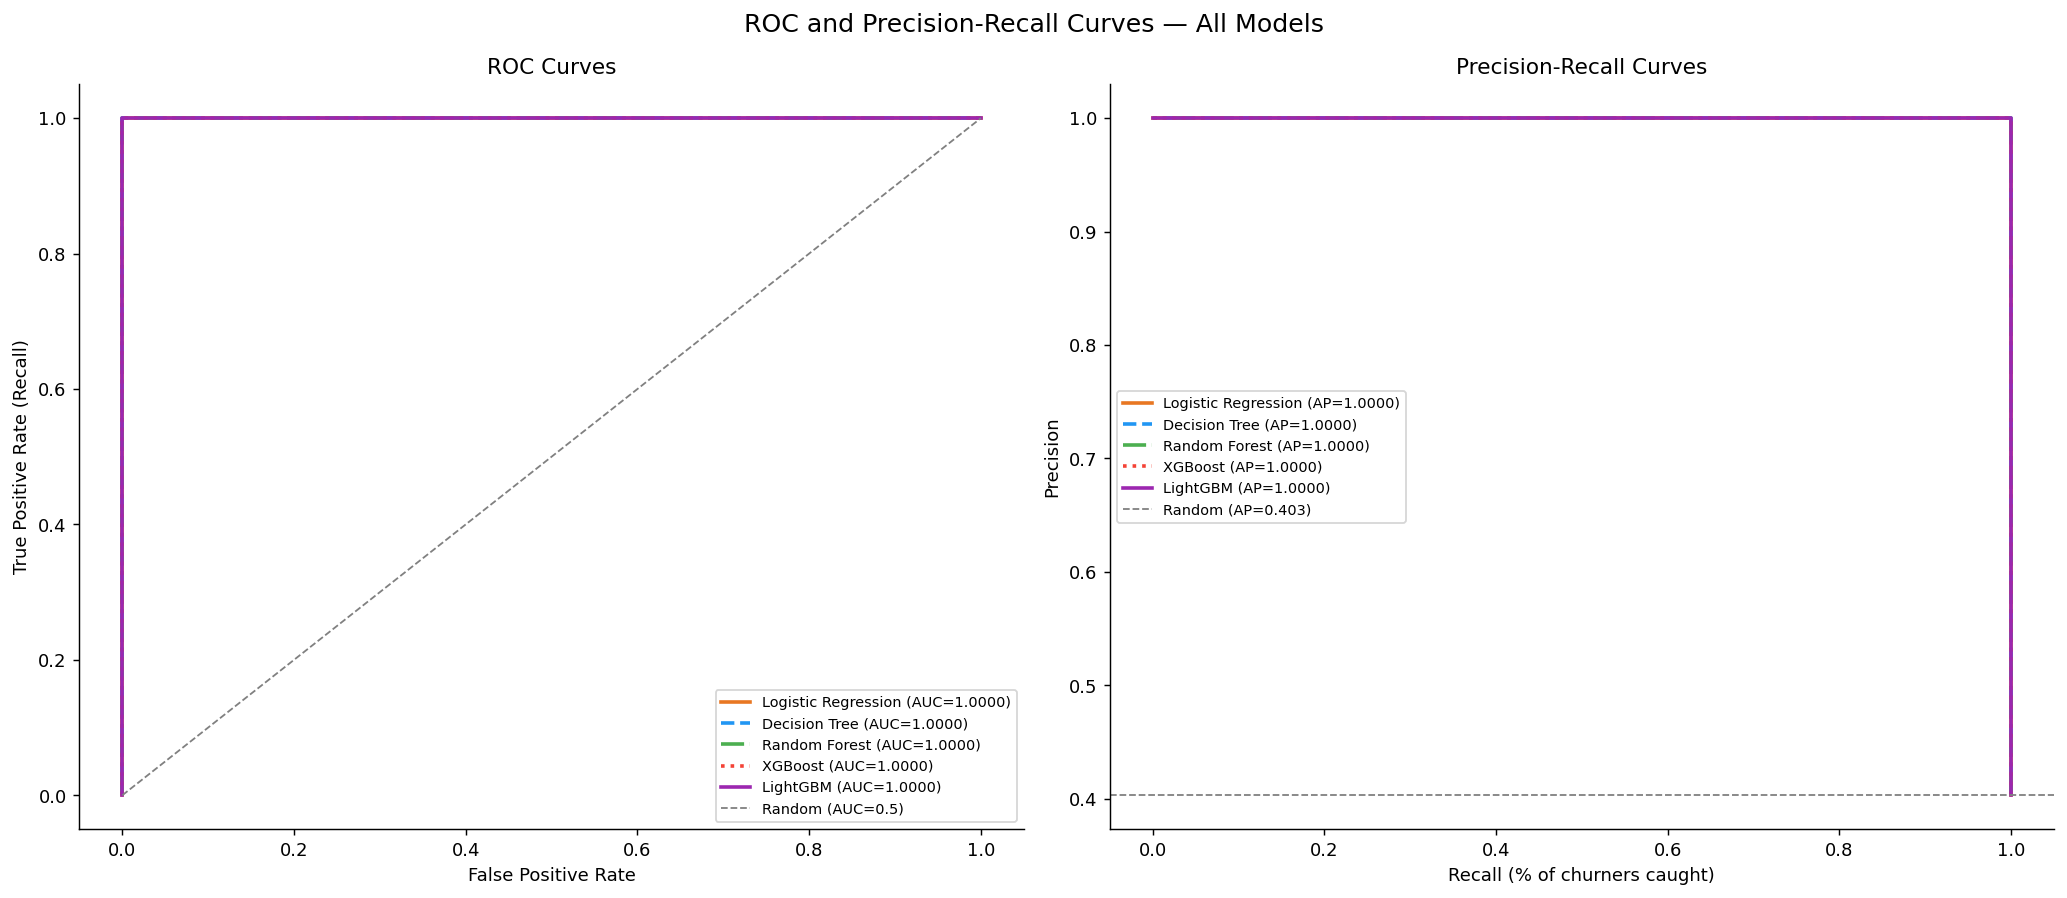

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("ROC and Precision-Recall Curves — All Models",
             fontsize=14)

line_styles = ["-","--","-.",":","-"]
colors_m    = ["#E87722","#2196F3","#4CAF50","#F44336","#9C27B0"]

for idx, result in enumerate(results_list):
    # ROC
    fpr, tpr, _ = roc_curve(y_test, result["y_prob"])
    axes[0].plot(fpr, tpr,
                 color=colors_m[idx],
                 linestyle=line_styles[idx],
                 linewidth=2,
                 label=f"{result['model']} "
                       f"(AUC={result['roc_auc']:.4f})")
    # PR
    prec_c, rec_c, _ = precision_recall_curve(
        y_test, result["y_prob"]
    )
    axes[1].plot(rec_c, prec_c,
                 color=colors_m[idx],
                 linestyle=line_styles[idx],
                 linewidth=2,
                 label=f"{result['model']} "
                       f"(AP={result['avg_precision']:.4f})")

# Random classifier baselines
axes[0].plot([0,1],[0,1], "gray", linestyle="--",
             linewidth=1, label="Random (AUC=0.5)")
axes[1].axhline(y_test.mean(), color="gray",
                linestyle="--", linewidth=1,
                label=f"Random (AP={y_test.mean():.3f})")

axes[0].set_title("ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].legend(fontsize=8)

axes[1].set_title("Precision-Recall Curves")
axes[1].set_xlabel("Recall (% of churners caught)")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/model_01_roc_pr_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()

THRESHOLD OPTIMIZATION — Business Cost Minimization

Optimizing threshold for: Logistic Regression



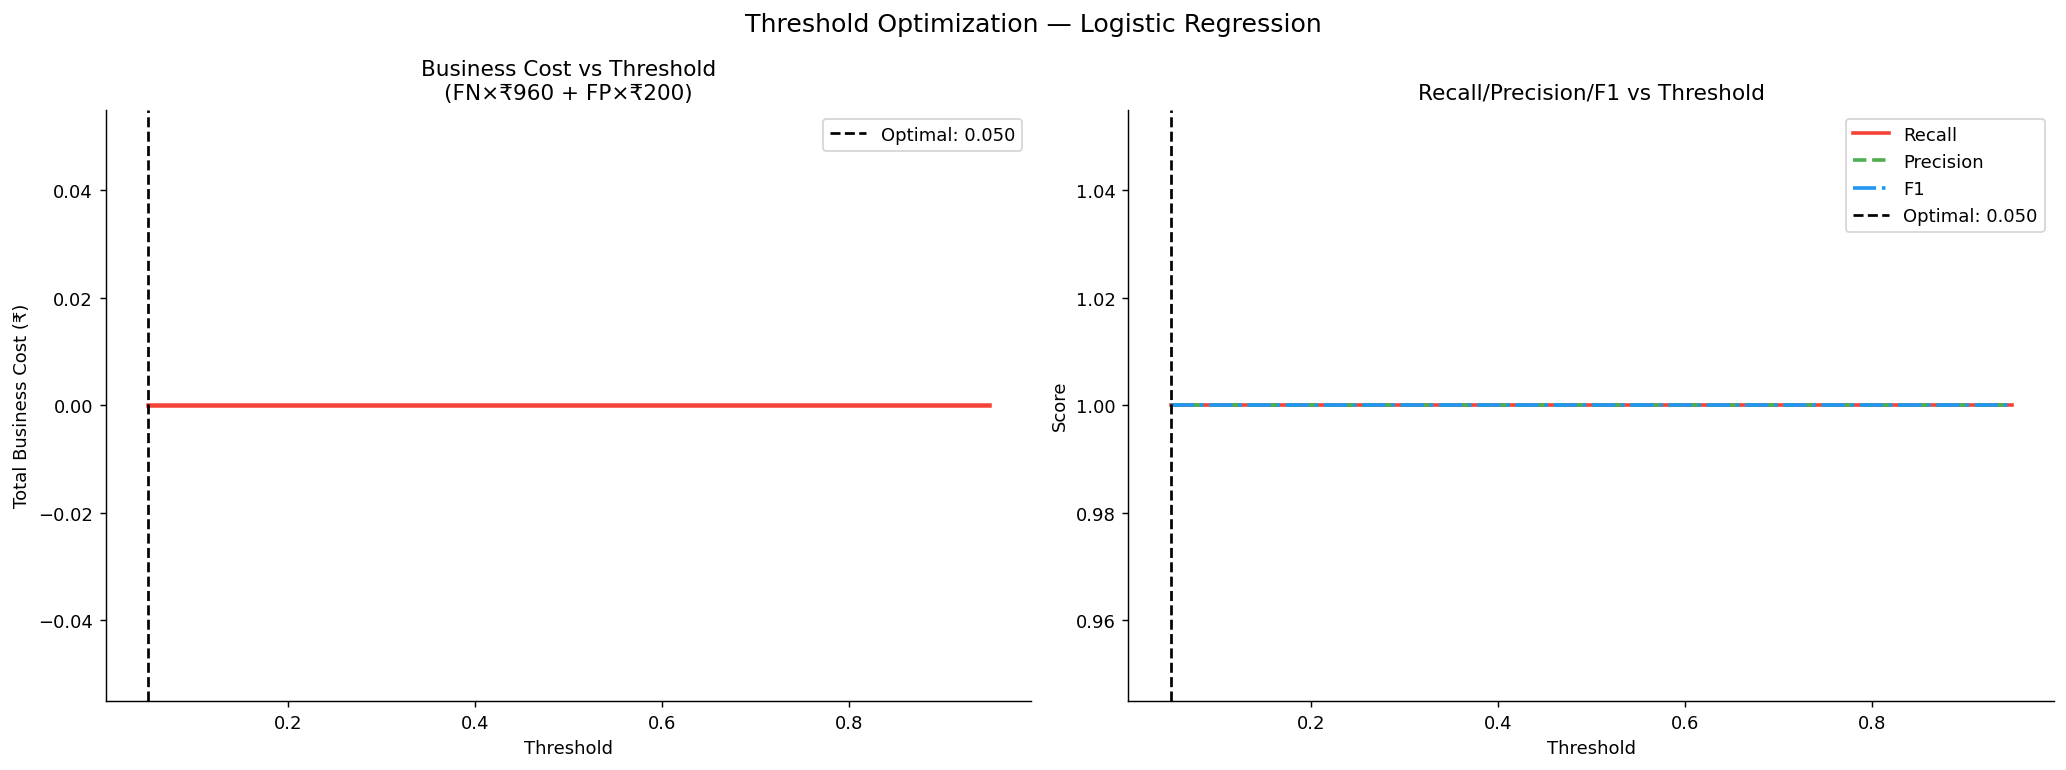

At optimal threshold (0.0500):
  Recall       : 1.0000
  Precision    : 1.0000
  F1           : 1.0000
  TP (caught)  : 403
  FN (missed)  : 0
  FP (alarm)   : 0
  Business cost: ₹0

At default threshold (0.5):
  Business cost: ₹0
  Savings from threshold tuning: ₹0


In [9]:
print("THRESHOLD OPTIMIZATION — Business Cost Minimization\n")

best_model_result = max(
    results_list, key=lambda r: r["roc_auc"]
)
best_name  = best_model_result["model"]
best_probs = best_model_result["y_prob"]

print(f"Optimizing threshold for: {best_name}\n")

thresholds    = np.linspace(0.05, 0.95, 200)
costs         = []
recalls       = []
precisions    = []
f1_scores     = []

for thresh in thresholds:
    y_pred_t = (best_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    cost = fn * COST_FN + fp * COST_FP
    costs.append(cost)
    recalls.append(recall_score(y_test, y_pred_t,
                                zero_division=0))
    precisions.append(precision_score(y_test, y_pred_t,
                                      zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_t,
                              zero_division=0))

optimal_idx    = np.argmin(costs)
optimal_thresh = thresholds[optimal_idx]
optimal_cost   = costs[optimal_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Threshold Optimization — {best_name}",
             fontsize=14)

axes[0].plot(thresholds, costs,
             color="#F44336", linewidth=2.5)
axes[0].axvline(optimal_thresh, color="black",
                linestyle="--", linewidth=1.5,
                label=f"Optimal: {optimal_thresh:.3f}")
axes[0].set_title("Business Cost vs Threshold\n"
                  "(FN×₹960 + FP×₹200)")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Total Business Cost (₹)")
axes[0].legend()

axes[1].plot(thresholds, recalls,
             color="#F44336", linewidth=2, label="Recall")
axes[1].plot(thresholds, precisions,
             color="#4CAF50", linewidth=2,
             linestyle="--", label="Precision")
axes[1].plot(thresholds, f1_scores,
             color="#2196F3", linewidth=2,
             linestyle="-.", label="F1")
axes[1].axvline(optimal_thresh, color="black",
                linestyle="--", linewidth=1.5,
                label=f"Optimal: {optimal_thresh:.3f}")
axes[1].set_title("Recall/Precision/F1 vs Threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/model_02_threshold_opt.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Evaluate best model at optimal threshold
optimal_result = evaluate_model(
    f"{best_name} (optimal threshold)",
    y_test,
    (best_probs >= optimal_thresh).astype(int),
    best_probs,
    threshold=optimal_thresh
)

print(f"At optimal threshold ({optimal_thresh:.4f}):")
print(f"  Recall       : {optimal_result['recall']:.4f}")
print(f"  Precision    : {optimal_result['precision']:.4f}")
print(f"  F1           : {optimal_result['f1']:.4f}")
print(f"  TP (caught)  : {optimal_result['tp']}")
print(f"  FN (missed)  : {optimal_result['fn']}")
print(f"  FP (alarm)   : {optimal_result['fp']}")
print(f"  Business cost: ₹{optimal_result['business_cost']:,}")
print(f"\nAt default threshold (0.5):")
print(f"  Business cost: ₹{best_model_result['business_cost']:,}")
default_cost = best_model_result["business_cost"]
savings = default_cost - optimal_result["business_cost"]
print(f"  Savings from threshold tuning: ₹{savings:,}")

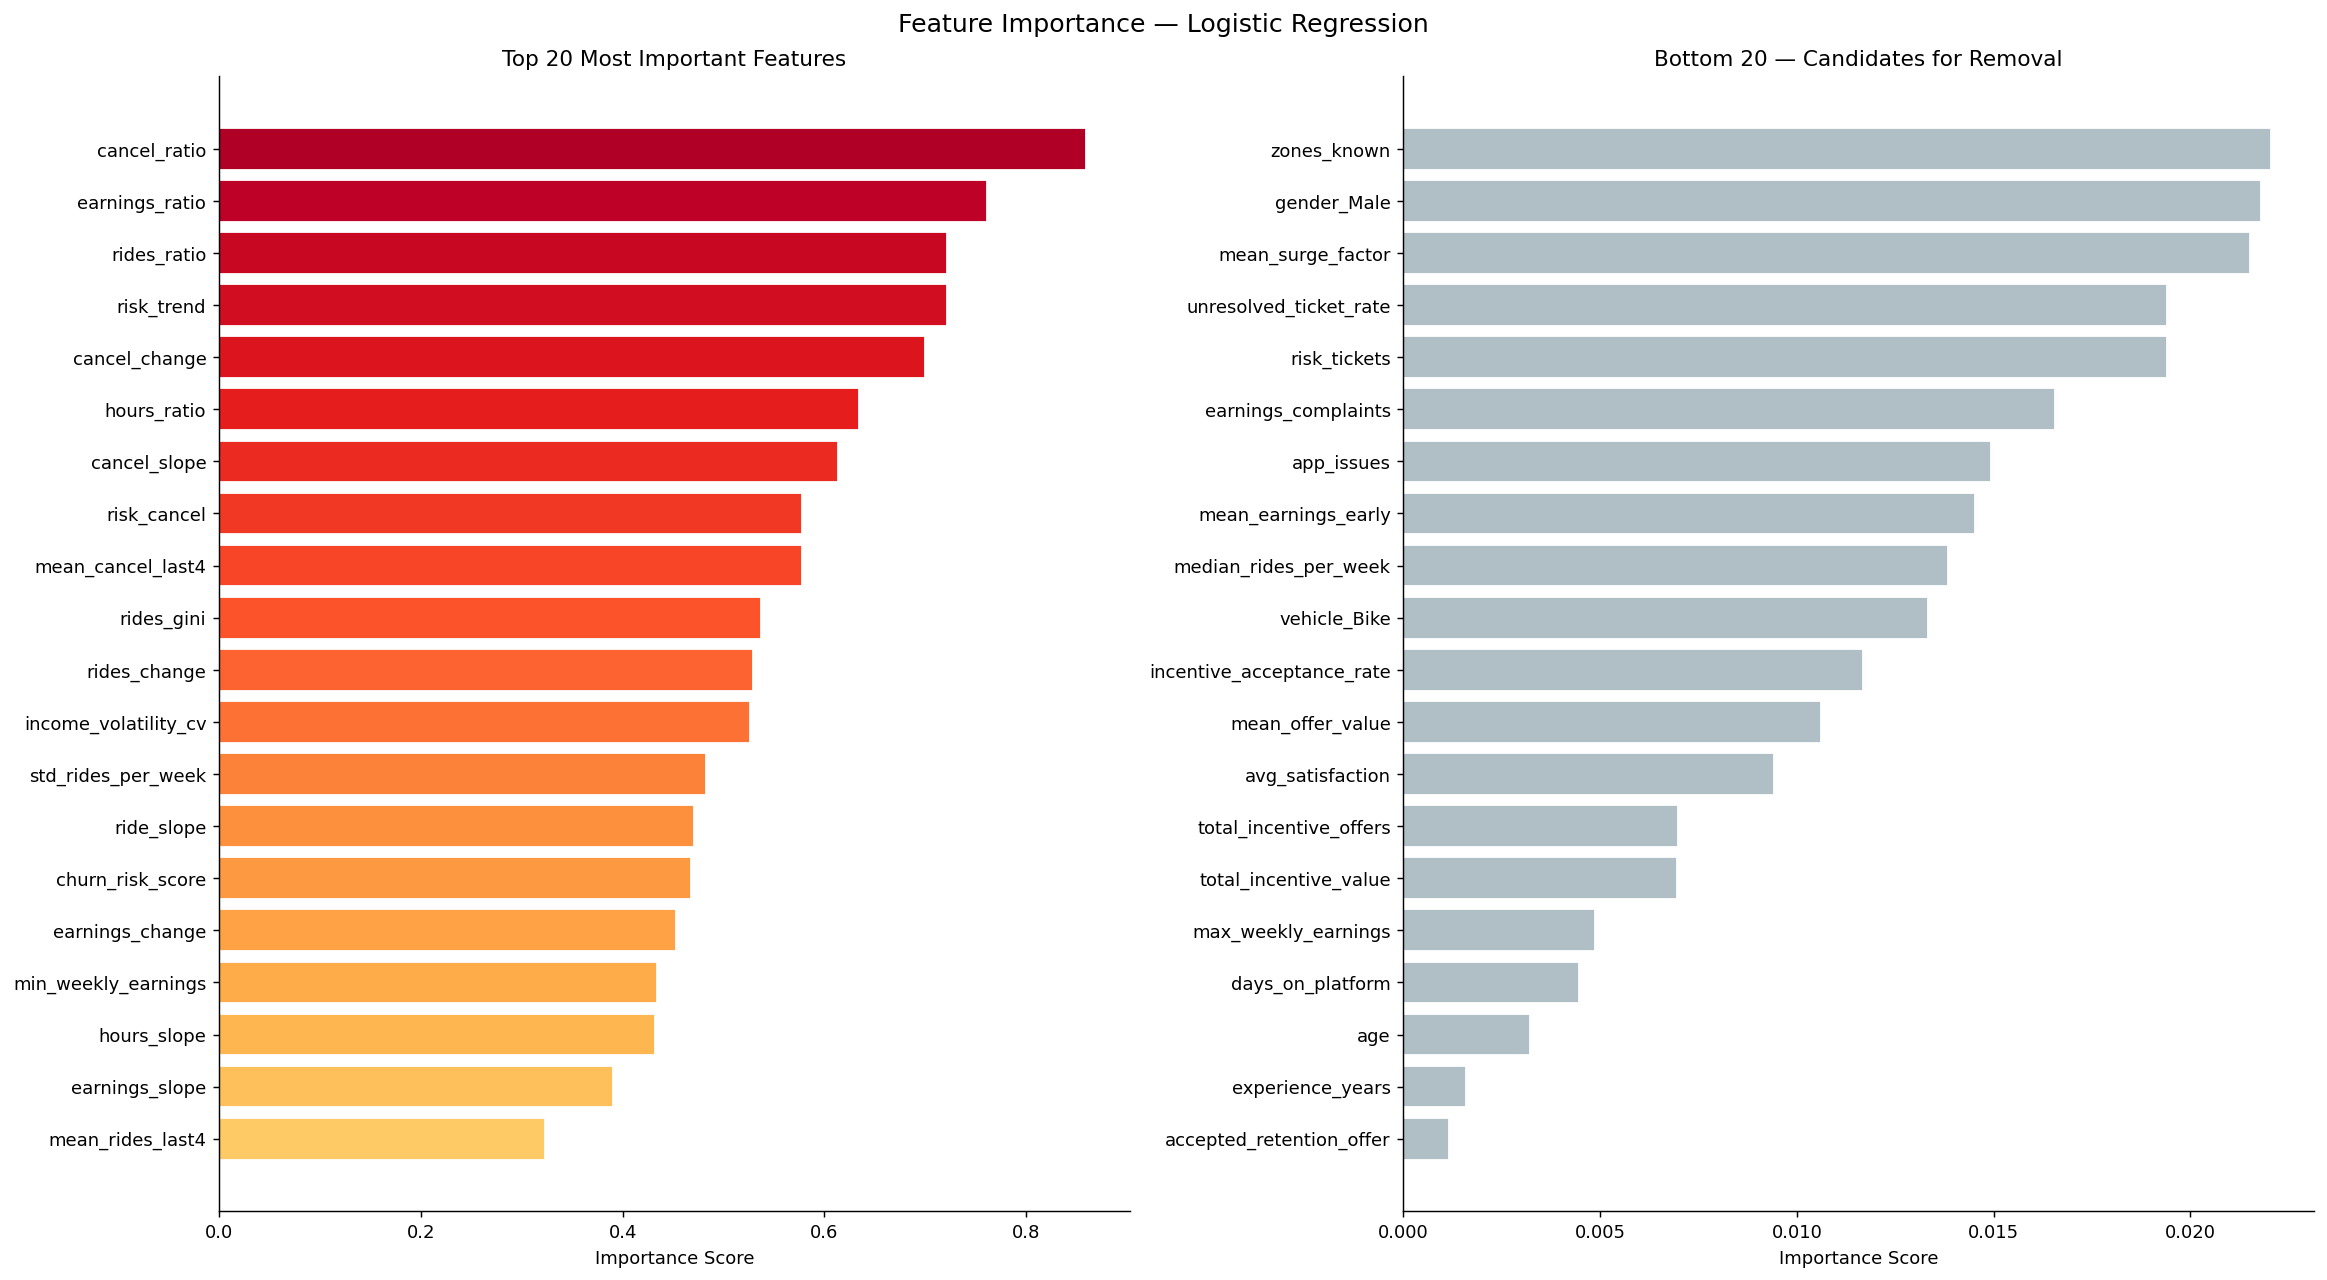

Importance source: absolute coefficients
Top 15 features:
cancel_ratio           0.8594
earnings_ratio         0.7614
rides_ratio            0.7218
risk_trend             0.7218
cancel_change          0.6999
hours_ratio            0.6339
cancel_slope           0.6134
risk_cancel            0.5777
mean_cancel_last4      0.5777
rides_gini             0.5370
rides_change           0.5288
income_volatility_cv   0.5259
std_rides_per_week     0.4824
ride_slope             0.4710
churn_risk_score       0.4674
dtype: float64

Validation — EDA predicted these would dominate:
  rides_ratio, cancel_change, cancel_slope
  Model says: ['cancel_ratio', 'earnings_ratio', 'rides_ratio']

Features with importance < 0.001: 0
  These can be dropped for a leaner production model


In [13]:
best_model_obj = trained_models[best_name]

if hasattr(best_model_obj, "feature_importances_"):
    importances = pd.Series(
        best_model_obj.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)
    importance_source = "feature_importances_"

elif hasattr(best_model_obj, "coef_"):
    coef_values = np.abs(best_model_obj.coef_).ravel()
    importances = pd.Series(
        coef_values,
        index=feature_cols
    ).sort_values(ascending=False)
    importance_source = "absolute coefficients"

else:
    importances = pd.Series(
        np.zeros(len(feature_cols)),
        index=feature_cols
    )
    importance_source = "no built-in importance available"

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle(f"Feature Importance — {best_name}",
             fontsize=14)

# Top 20
top20 = importances.head(20)
colors = plt.cm.YlOrRd(
    np.linspace(0.3, 0.9, len(top20))
)[::-1]
axes[0].barh(top20.index, top20.values,
             color=colors, edgecolor="white")
axes[0].set_title("Top 20 Most Important Features")
axes[0].set_xlabel("Importance Score")
axes[0].invert_yaxis()

# Bottom 20 — features to consider dropping
bottom20 = importances.tail(20)
axes[1].barh(bottom20.index, bottom20.values,
             color="#B0BEC5", edgecolor="white")
axes[1].set_title("Bottom 20 — Candidates for Removal")
axes[1].set_xlabel("Importance Score")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../data/processed/model_03_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Importance source: {importance_source}")
print(f"Top 15 features:")
print(importances.head(15).round(5))

print(f"\nValidation — EDA predicted these would dominate:")
print(f"  rides_ratio, cancel_change, cancel_slope")
top3 = importances.head(3).index.tolist()
print(f"  Model says: {top3}")

# Features with near-zero importance
zero_importance = (importances < 0.001).sum()
print(f"\nFeatures with importance < 0.001: {zero_importance}")
print(f"  These can be dropped for a leaner production model")

5-Fold Stratified Cross Validation — Top 3 Models

  Logistic Regression       CV AUC: 1.0000 ± 0.0000  |  Test AUC: 1.0000
  Decision Tree             CV AUC: 1.0000 ± 0.0000  |  Test AUC: 1.0000
  Random Forest             CV AUC: 1.0000 ± 0.0000  |  Test AUC: 1.0000


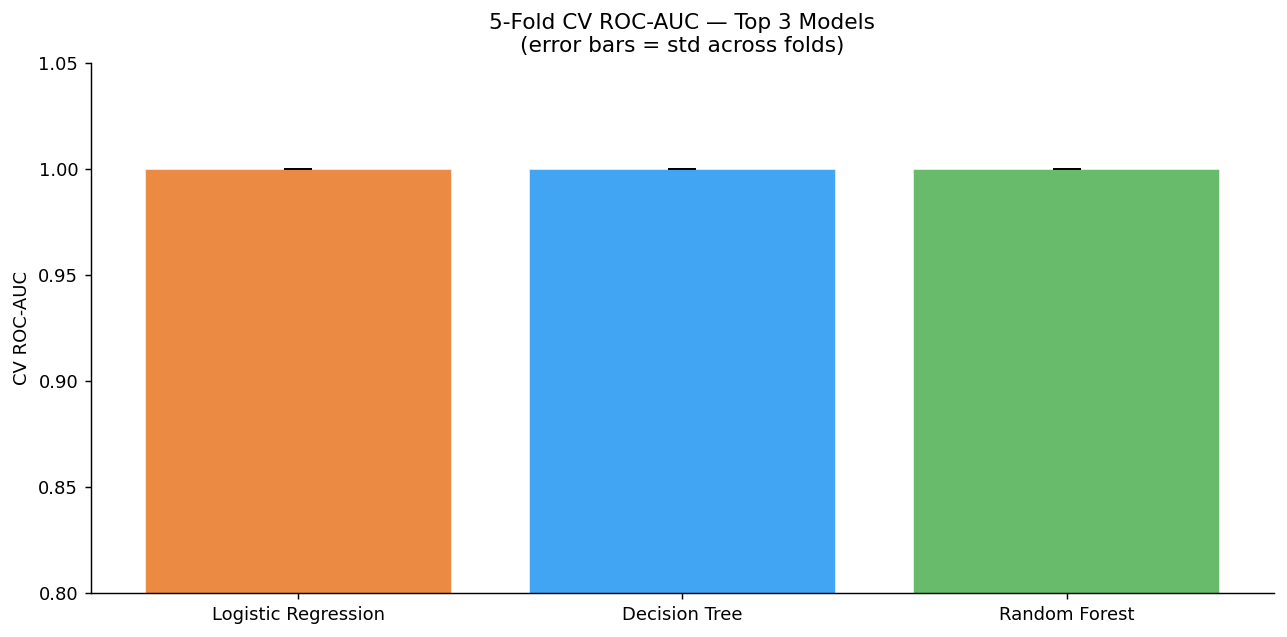

In [14]:
print("5-Fold Stratified Cross Validation — Top 3 Models\n")

top3_names = results_df["model"].head(3).tolist()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name in top3_names:
    model = trained_models[name]

    if name == "Logistic Regression":
        X_cv, y_cv = X_train_scaled, y_train
    else:
        X_cv, y_cv = X_train, y_train

    cv_scores = cross_val_score(
        model, X_cv, y_cv,
        cv=skf, scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "model"         : name,
        "cv_auc_mean"   : cv_scores.mean(),
        "cv_auc_std"    : cv_scores.std(),
        "test_auc"      : results_df[
            results_df["model"]==name
        ]["roc_auc"].values[0],
    })

    print(f"  {name:<25} "
          f"CV AUC: {cv_scores.mean():.4f} ± "
          f"{cv_scores.std():.4f}  |  "
          f"Test AUC: {results_df[results_df['model']==name]['roc_auc'].values[0]:.4f}")

cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(10, 5))
x_pos   = np.arange(len(cv_df))
colors  = ["#E87722","#2196F3","#4CAF50"]

ax.bar(x_pos, cv_df["cv_auc_mean"],
       yerr=cv_df["cv_auc_std"],
       color=colors, edgecolor="white",
       capsize=8, alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(cv_df["model"])
ax.set_title("5-Fold CV ROC-AUC — Top 3 Models\n"
             "(error bars = std across folds)")
ax.set_ylabel("CV ROC-AUC")
ax.set_ylim(0.8, 1.05)

plt.tight_layout()
plt.savefig("../data/processed/model_04_cross_validation.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [15]:
import os
MODELS_DIR = "../models/"
os.makedirs(MODELS_DIR, exist_ok=True)

model_filename = (
    f"{best_name.lower().replace(' ','_')}_churn.pkl"
)
with open(MODELS_DIR + model_filename, "wb") as f:
    pickle.dump(trained_models[best_name], f)

with open(MODELS_DIR + "scaler_churn.pkl", "wb") as f:
    pickle.dump(scaler, f)

results_df.drop(
    columns=["y_prob","y_pred"], errors="ignore"
).to_csv(PATH + "model_comparison_results.csv", index=False)

# Save optimal threshold
with open(PATH + "optimal_threshold.pkl", "wb") as f:
    pickle.dump(optimal_thresh, f)

print(f"✅ Best model saved : models/{model_filename}")
print(f"✅ Scaler saved     : models/scaler_churn.pkl")
print(f"✅ Results saved    : data/processed/model_comparison_results.csv")
print(f"✅ Optimal threshold: {optimal_thresh:.4f}")

✅ Best model saved : models/logistic_regression_churn.pkl
✅ Scaler saved     : models/scaler_churn.pkl
✅ Results saved    : data/processed/model_comparison_results.csv
✅ Optimal threshold: 0.0500
